In [1]:
# 기본 라이브러리 불러오기
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 시각화 기본 설정
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

# 실행 위치 설정
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR.parent / "shared"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
MODEL_PATH = OUTPUT_DIR / "model.pkl"

print("BASE_DIR:", BASE_DIR)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("MODEL_PATH:", MODEL_PATH)

BASE_DIR: C:\mission15\mission15_김기현\mission-result\researcher1
TRAIN_PATH: C:\mission15\mission15_김기현\mission-result\researcher1\data\train.csv
TEST_PATH: C:\mission15\mission15_김기현\mission-result\researcher1\data\test.csv
MODEL_PATH: C:\mission15\mission15_김기현\mission-result\shared\model.pkl


## 1. 데이터 로드

In [2]:
# 데이터 로드
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print(train_df.head())
print(test_df.head())

train shape: (7000, 6)
test shape: (3000, 5)
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              6               73                         No            7   
1              1               89                        Yes            7   
2              3               97                        Yes            8   
3              8               70                         No            5   
4              7               94                        Yes            7   

   Sample Question Papers Practiced  Performance Index  
0                                 2               58.0  
1                                 2               64.0  
2                                 0               75.0  
3                                 5               59.0  
4                                 4               86.0  
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9

In [3]:
# 컬럼별 타입과 결측치 확인
summary = pd.DataFrame({
    "dtype": train_df.dtypes,
    "missing_count": train_df.isna().sum(),
    "missing_ratio": train_df.isna().mean(),
    "nunique": train_df.nunique()
})
summary

,dtype,missing_count,missing_ratio,nunique
Hours Studied,int64,0,0.0,9
Previous Scores,int64,0,0.0,60
Extracurricular Activities,object,0,0.0,2
Sleep Hours,int64,0,0.0,6
Sample Question Papers Practiced,int64,0,0.0,10
Performance Index,float64,0,0.0,91


## 2. EDA - 목표변수 분포

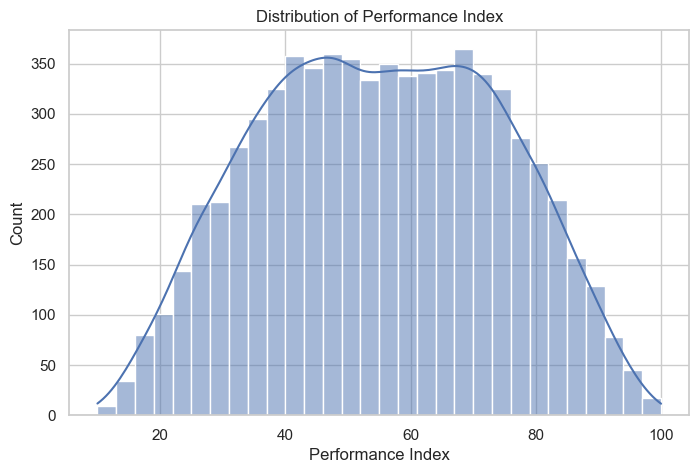

count    7000.000000
mean       55.095143
std        19.151574
min        10.000000
25%        40.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: Performance Index, dtype: float64

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["Performance Index"], bins=30, kde=True)
plt.title("Distribution of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Count")
plt.show()

train_df["Performance Index"].describe()

## 3. EDA - 숫자형 변수 분포 

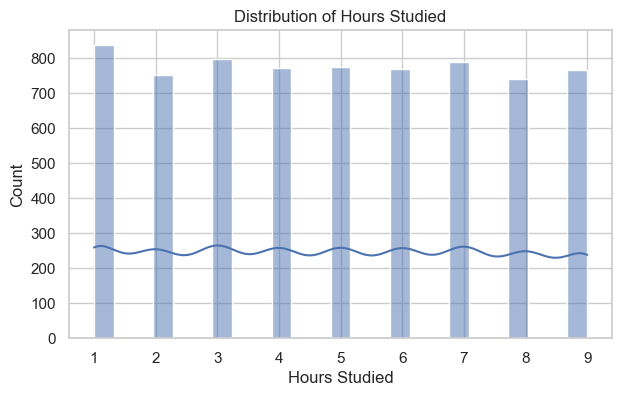

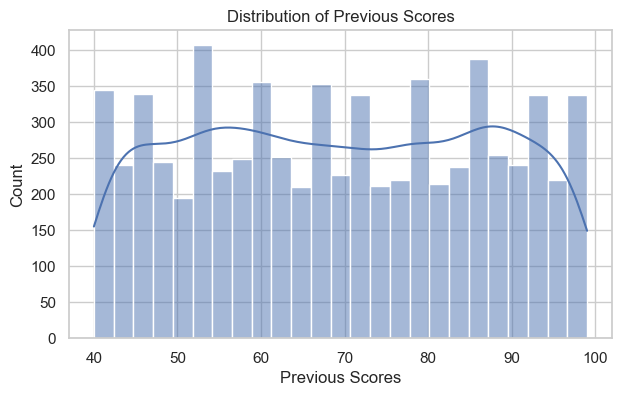

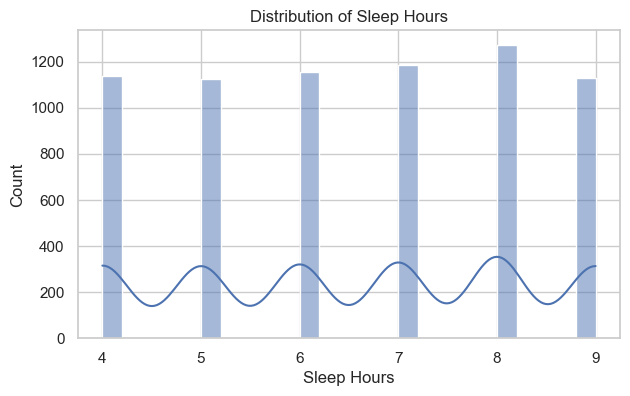

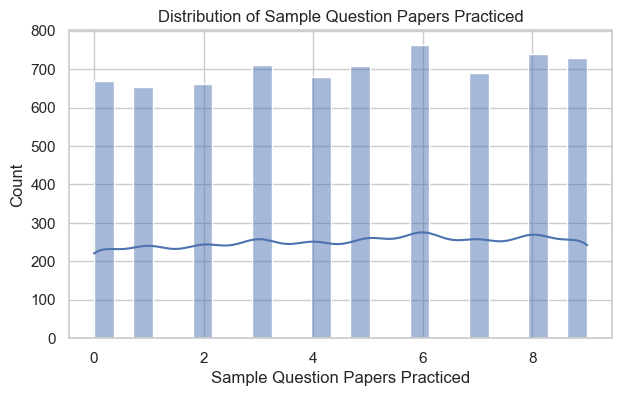

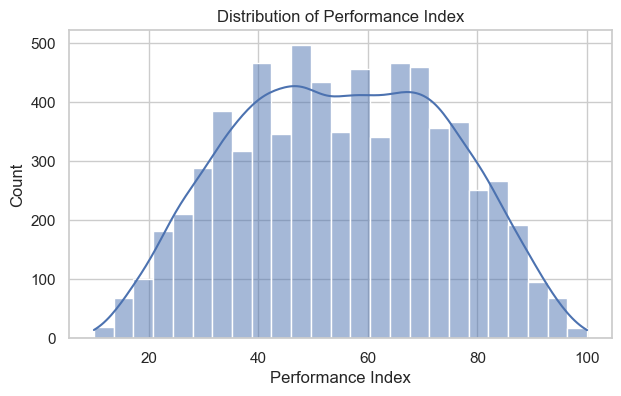

In [5]:
numeric_cols = train_df.select_dtypes(exclude="object").columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col], bins=25, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 4. EDA - 범주형 변수와 목표변수 관계 

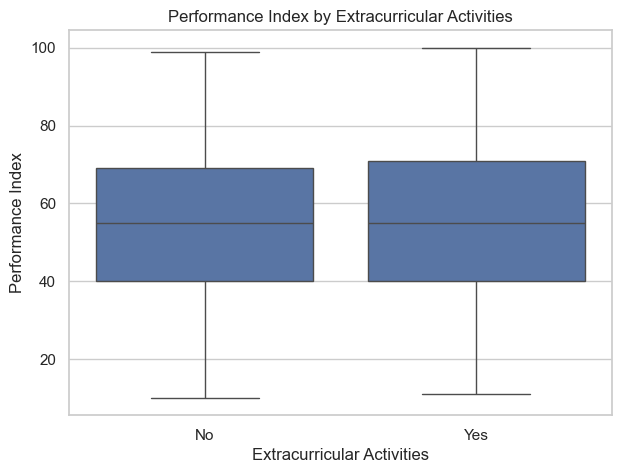

,count,mean,std,min,max
Extracurricular Activities,,,,,
No,3522,54.613572,19.122017,10.0,99.0
Yes,3478,55.582806,19.171881,11.0,100.0


In [6]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df, x="Extracurricular Activities", y="Performance Index")
plt.title("Performance Index by Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Performance Index")
plt.show()

activity_summary = train_df.groupby("Extracurricular Activities")["Performance Index"].agg(["count", "mean", "std", "min", "max"])
activity_summary

## 5. EDA - 상관관계 분석

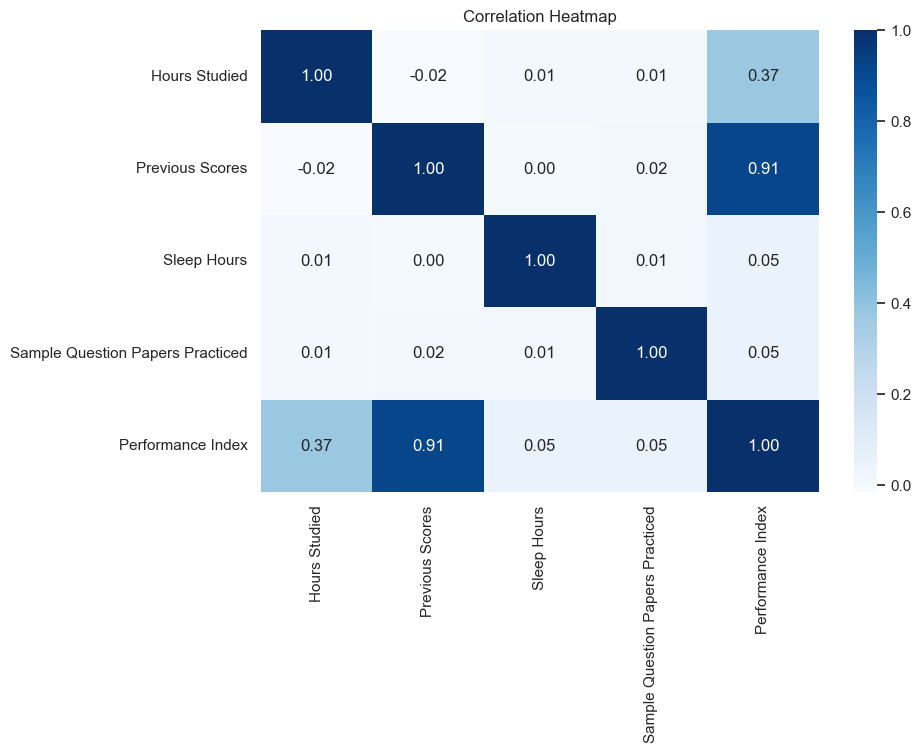

In [7]:
corr = train_df.select_dtypes(exclude="object").corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

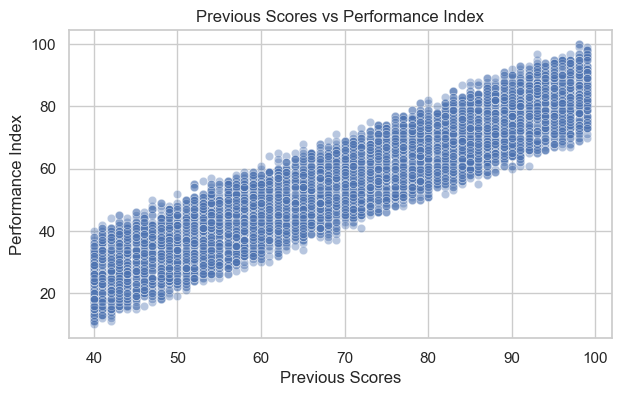

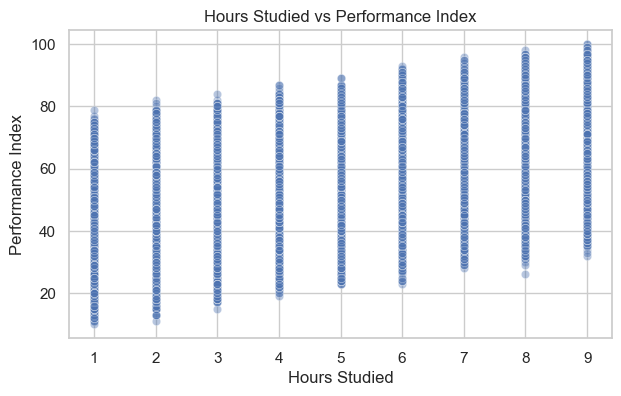

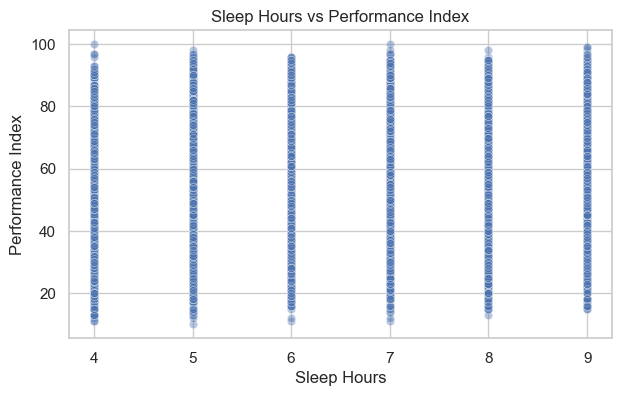

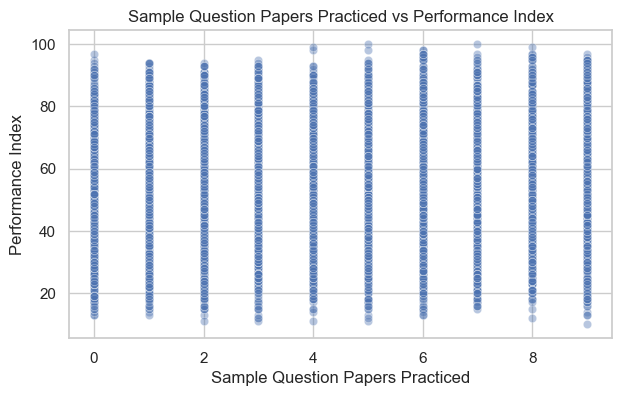

In [8]:
# 주요 변수와 목표변수의 산점도 확인
for col in ["Previous Scores", "Hours Studied", "Sleep Hours", "Sample Question Papers Practiced"]:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=train_df, x=col, y="Performance Index", alpha=0.4)
    plt.title(f"{col} vs Performance Index")
    plt.xlabel(col)
    plt.ylabel("Performance Index")
    plt.show()

## 6. 전처리 및 모델링 파이프라인

In [9]:
target_col = "Performance Index"
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

numeric_features = X.select_dtypes(exclude="object").columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

numeric_features: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
categorical_features: ['Extracurricular Activities']
X_train: (5600, 5)
X_valid: (1400, 5)


## 7. 여러 회귀 모델 비교

In [10]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
trained_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    rmse = root_mean_squared_error(y_valid, pred)
    r2 = r2_score(y_valid, pred)
    results.append({"model": name, "RMSE": rmse, "R2": r2})
    trained_pipelines[name] = pipe

result_df = pd.DataFrame(results).sort_values("RMSE")
result_df

,model,RMSE,R2
0,LinearRegression,2.010259,0.989281
1,Ridge,2.010485,0.989279
3,GradientBoosting,2.081904,0.988503
2,RandomForest,2.248582,0.986589


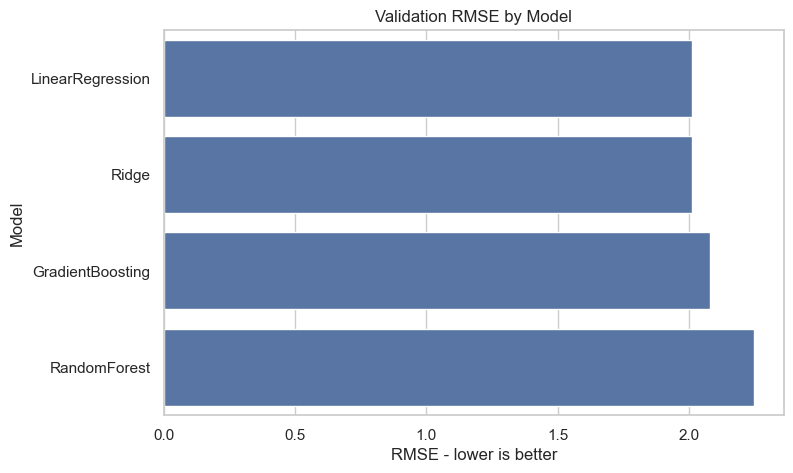

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=result_df, x="RMSE", y="model")
plt.title("Validation RMSE by Model")
plt.xlabel("RMSE - lower is better")
plt.ylabel("Model")
plt.show()

## 8. 최종 모델 선택 및 오차 시각화

Best model: LinearRegression
Validation RMSE: 2.0102592175992644
Validation R2: 0.9892810498471765


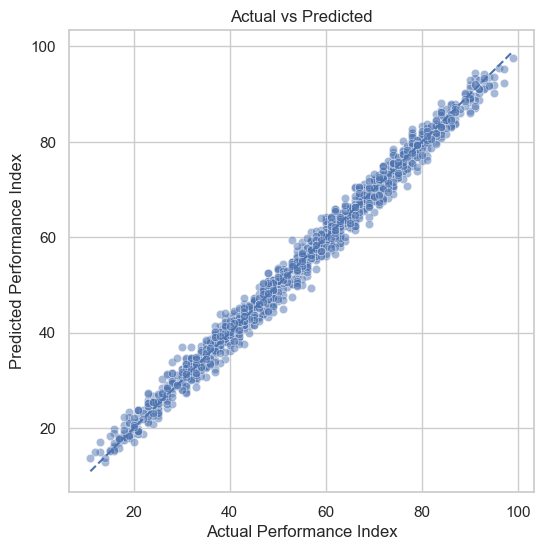

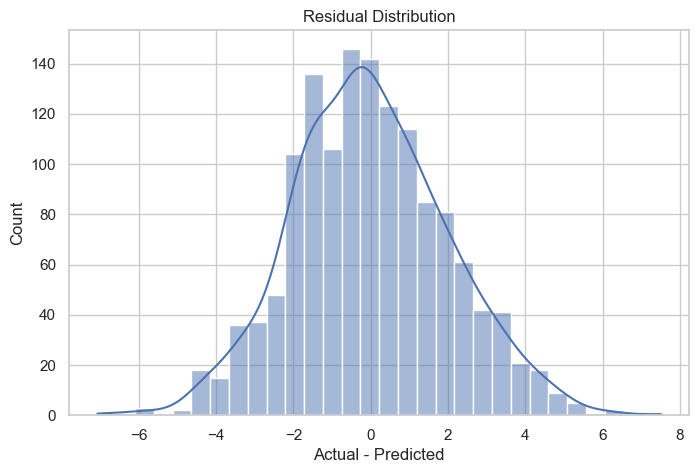

In [12]:
best_model_name = result_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]
valid_pred = best_pipeline.predict(X_valid)

print("Best model:", best_model_name)
print("Validation RMSE:", root_mean_squared_error(y_valid, valid_pred))
print("Validation R2:", r2_score(y_valid, valid_pred))

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_valid, y=valid_pred, alpha=0.5)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], "--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.show()

residuals = y_valid - valid_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Count")
plt.show()

## 9. 전체 학습 데이터로 최종 모델 재학습 및 저장

In [13]:
# 가장 성능이 좋았던 모델 종류를 그대로 사용해서 전체 데이터로 재학습
final_estimator = models[best_model_name]
final_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", final_estimator)
])

final_pipeline.fit(X, y)
joblib.dump(final_pipeline, MODEL_PATH)

# 연구자 2가 사용할 test.csv도 shared 폴더로 복사
shared_test_path = OUTPUT_DIR / "test.csv"
test_df.to_csv(shared_test_path, index=False)

metrics = {
    "best_model": best_model_name,
    "validation_rmse": float(root_mean_squared_error(y_valid, valid_pred)),
    "validation_r2": float(r2_score(y_valid, valid_pred)),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print("model saved:", MODEL_PATH)
print("test.csv copied:", shared_test_path)
print(metrics)

model saved: C:\mission15\mission15_김기현\mission-result\shared\model.pkl
test.csv copied: C:\mission15\mission15_김기현\mission-result\shared\test.csv
{'best_model': 'LinearRegression', 'validation_rmse': 2.0102592175992644, 'validation_r2': 0.9892810498471765, 'train_rows': 7000, 'test_rows': 3000}
